In [1]:
import pandas as pd
import numpy as np

prices_df = pd.read_csv("data/nifty20_prices.csv", 
                         index_col=0, 
                         parse_dates=True)

# Monthly returns — base for everything
monthly_returns = prices_df.pct_change(1)
monthly_returns = monthly_returns.dropna(how='all')

# Factor 1 — Momentum (12-1)
momentum_scores = prices_df.shift(1).pct_change(11)
momentum_scores = momentum_scores[momentum_scores.index >= "2019-01-01"]

# Factor 2 — Volatility (12 month rolling std of returns)
# Inverted — low vol gets high score
vol_scores = monthly_returns.rolling(12).std() * -1
vol_scores = vol_scores[vol_scores.index >= "2019-01-01"]

# Factor 3 — Short Term Reversal (last month return inverted)
reversal_scores = monthly_returns * -1
reversal_scores = reversal_scores[reversal_scores.index >= "2019-01-01"]

print("Momentum shape:", momentum_scores.shape)
print("Vol shape:", vol_scores.shape)
print("Reversal shape:", reversal_scores.shape)

Momentum shape: (88, 18)
Vol shape: (86, 18)
Reversal shape: (86, 18)


In [2]:
# Find the common start date — latest of all three
common_start = max(
    momentum_scores.dropna(how='all').index[0],
    vol_scores.dropna(how='all').index[0],
    reversal_scores.dropna(how='all').index[0]
)

print("Common start date:", common_start)

# Filter all three to same date range
momentum_scores = momentum_scores[momentum_scores.index >= common_start]
vol_scores = vol_scores[vol_scores.index >= common_start]
reversal_scores = reversal_scores[reversal_scores.index >= common_start]

print("Momentum shape:", momentum_scores.shape)
print("Vol shape:", vol_scores.shape)
print("Reversal shape:", reversal_scores.shape)

Common start date: 2020-03-31 00:00:00
Momentum shape: (73, 18)
Vol shape: (73, 18)
Reversal shape: (73, 18)


In [3]:
# Rank each factor across stocks within each month
# axis=1 means ranking across columns (stocks) within each row (month)

momentum_ranks = momentum_scores.rank(axis=1)
vol_ranks = vol_scores.rank(axis=1)
reversal_ranks = reversal_scores.rank(axis=1)

# Quick check — each row should have ranks 1 through 18
print("Sample momentum ranks:")
print(momentum_ranks.tail(3))

print("\nSample vol ranks:")
print(vol_ranks.tail(3))

Sample momentum ranks:
            RELIANCE  TCS  HDFCBANK  INFY  HINDUNILVR  ICICIBANK  KOTAKBANK  \
2026-01-30      13.0  1.0      11.0   3.0         5.0        8.0        9.0   
2026-02-27      12.0  3.0       7.0   4.0         9.0       11.0        6.0   
2026-03-27      12.0  1.0       7.0   4.0        10.0        9.0        6.0   

            BAJFINANCE  BHARTIARTL  ITC  AXISBANK  MARUTI  SUNPHARMA  TITAN  \
2026-01-30        14.0        16.0  4.0      15.0    18.0        7.0   10.0   
2026-02-27         8.0        14.0  1.0      17.0    13.0        5.0   16.0   
2026-03-27        13.0        11.0  2.0      15.0    16.0        8.0   18.0   

            WIPRO  HCLTECH  JSWSTEEL  TATASTEEL  
2026-01-30    2.0      6.0      12.0       17.0  
2026-02-27    2.0     10.0      15.0       18.0  
2026-03-27    3.0      5.0      14.0       17.0  

Sample vol ranks:
            RELIANCE  TCS  HDFCBANK  INFY  HINDUNILVR  ICICIBANK  KOTAKBANK  \
2026-01-30       5.0  7.0      18.0  15.0    

In [4]:
# Average the three factor ranks equally
combined_scores = (momentum_ranks + vol_ranks + reversal_ranks) / 3

print("Combined scores shape:", combined_scores.shape)
print("\nLatest combined scores:")
latest_combined = combined_scores.iloc[-1].sort_values(ascending=False)
print(latest_combined)
print("\nTop 3 combined stocks:", latest_combined.head(3).index.tolist())
print("Bottom 3 combined stocks:", latest_combined.tail(3).index.tolist())

Combined scores shape: (73, 18)

Latest combined scores:
JSWSTEEL      13.000000
HINDUNILVR    13.000000
ICICIBANK     12.666667
HDFCBANK      12.333333
AXISBANK      12.333333
MARUTI        11.666667
KOTAKBANK     11.666667
BAJFINANCE    11.333333
BHARTIARTL    10.333333
TITAN         10.333333
TATASTEEL      9.666667
RELIANCE       9.333333
ITC            7.000000
TCS            6.333333
SUNPHARMA      6.333333
WIPRO          6.000000
INFY           4.666667
HCLTECH        3.000000
Name: 2026-03-27 00:00:00, dtype: float64

Top 3 combined stocks: ['JSWSTEEL', 'HINDUNILVR', 'ICICIBANK']
Bottom 3 combined stocks: ['WIPRO', 'INFY', 'HCLTECH']


In [5]:
def build_portfolios(factor_scores, monthly_returns, n_quantiles=3):
    
    portfolio_returns = {f'Q{i+1}': {} for i in range(n_quantiles)}
    portfolio_returns['LS'] = {}
    
    for date in factor_scores.index:
        scores = factor_scores.loc[date].dropna()
        
        if len(scores) < 9:
            continue
        
        future_dates = monthly_returns.index[monthly_returns.index > date]
        if len(future_dates) == 0:
            continue
            
        next_date = future_dates[0]
        next_returns = monthly_returns.loc[next_date]
        
        quantile_labels = pd.qcut(scores, n_quantiles, 
                                   labels=['Q1', 'Q2', 'Q3'])
        
        for q in ['Q1', 'Q2', 'Q3']:
            stocks = scores[quantile_labels == q].index
            avg_ret = next_returns[stocks].mean()
            portfolio_returns[q][next_date] = avg_ret
        
        portfolio_returns['LS'][next_date] = (
            portfolio_returns['Q3'][next_date] - 
            portfolio_returns['Q1'][next_date]
        )
    
    return pd.DataFrame(portfolio_returns).dropna()

# Build combined portfolios
combined_portfolios = build_portfolios(combined_scores, monthly_returns)

print("Combined portfolio shape:", combined_portfolios.shape)
print(combined_portfolios.tail())

Combined portfolio shape: (72, 4)
                  Q1        Q2        Q3        LS
2025-11-28  0.031432  0.013757 -0.001497 -0.032929
2025-12-31  0.003615  0.019663 -0.012342 -0.015957
2026-01-30  0.005703 -0.058327 -0.040847 -0.046550
2026-02-27 -0.061746 -0.001444  0.002657  0.064403
2026-03-27 -0.080686 -0.051429 -0.103743 -0.023057


In [7]:
import numpy as np

def performance_summary(returns_series, name="Strategy"):
    
    ann_return = returns_series.mean() * 12
    ann_vol = returns_series.std() * np.sqrt(12)
    risk_free = 0.065
    sharpe = (ann_return - risk_free) / ann_vol
    
    cumulative = (1 + returns_series).cumprod()
    rolling_max = cumulative.expanding().max()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    win_rate = (returns_series > 0).mean()
    
    print(f"{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Annualized Return : {ann_return:.1%}")
    print(f"  Annualized Vol    : {ann_vol:.1%}")
    print(f"  Sharpe Ratio      : {sharpe:.2f}")
    print(f"  Max Drawdown      : {max_drawdown:.1%}")
    print(f"  Win Rate          : {win_rate:.1%}")
    print()
    
    return {
        'ann_return': ann_return,
        'ann_vol': ann_vol,
        'sharpe': sharpe,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate
    }

In [8]:
# Run performance for combined portfolios
results_combined = {}
for col in ['Q1', 'Q2', 'Q3', 'LS']:
    results_combined[col] = performance_summary(
        combined_portfolios[col].dropna(),
        name=f"Combined {col}"
    )

# Summary table
print("\nCOMBINED FACTOR SUMMARY TABLE")
print(f"{'Portfolio':<12} {'Ann.Return':>10} {'Sharpe':>8} {'MaxDD':>8}")
print("-" * 42)
for col in ['Q1', 'Q2', 'Q3', 'LS']:
    r = results_combined[col]
    print(f"{col:<12} {r['ann_return']:>10.1%} {r['sharpe']:>8.2f} {r['max_drawdown']:>8.1%}")

# Comparison against individual factors
print("\n" + "="*52)
print("FACTOR COMPARISON TABLE")
print(f"{'Factor':<22} {'Q3 Return':>10} {'Q3 Sharpe':>10} {'LS Sharpe':>10}")
print("-" * 52)

factors = {
    'Momentum':         (0.224, 0.92, -0.24),
    'Volatility':       (0.217, 0.89, -0.84),
    'Short Term Rev':   (0.237, 0.89,  0.38),
    'Combined':         (results_combined['Q3']['ann_return'],
                         results_combined['Q3']['sharpe'],
                         results_combined['LS']['sharpe'])
}

for name, (ret, q3_sharpe, ls_sharpe) in factors.items():
    print(f"{name:<22} {ret:>10.1%} {q3_sharpe:>10.2f} {ls_sharpe:>10.2f}")

  Combined Q1
  Annualized Return : 21.9%
  Annualized Vol    : 19.6%
  Sharpe Ratio      : 0.79
  Max Drawdown      : -17.8%
  Win Rate          : 63.9%

  Combined Q2
  Annualized Return : 21.8%
  Annualized Vol    : 17.2%
  Sharpe Ratio      : 0.89
  Max Drawdown      : -13.7%
  Win Rate          : 62.5%

  Combined Q3
  Annualized Return : 23.5%
  Annualized Vol    : 15.8%
  Sharpe Ratio      : 1.08
  Max Drawdown      : -15.0%
  Win Rate          : 62.5%

  Combined LS
  Annualized Return : 1.6%
  Annualized Vol    : 16.8%
  Sharpe Ratio      : -0.29
  Max Drawdown      : -27.8%
  Win Rate          : 51.4%


COMBINED FACTOR SUMMARY TABLE
Portfolio    Ann.Return   Sharpe    MaxDD
------------------------------------------
Q1                21.9%     0.79   -17.8%
Q2                21.8%     0.89   -13.7%
Q3                23.5%     1.08   -15.0%
LS                 1.6%    -0.29   -27.8%

FACTOR COMPARISON TABLE
Factor                  Q3 Return  Q3 Sharpe  LS Sharpe
---------------

In [10]:
combined_portfolios.to_csv("data/combined_portfolios.csv")
print("Saved combined portfolios")

Saved combined portfolios


In [11]:
import pandas as pd

momentum_portfolios = pd.read_csv("data/momentum_portfolios.csv", 
                                   index_col=0, parse_dates=True)
vol_portfolios      = pd.read_csv("data/vol_portfolios.csv", 
                                   index_col=0, parse_dates=True)
reversal_portfolios = pd.read_csv("data/reversal_portfolios.csv", 
                                   index_col=0, parse_dates=True)
combined_portfolios = pd.read_csv("data/combined_portfolios.csv", 
                                   index_col=0, parse_dates=True)

print("Momentum:", momentum_portfolios.shape)
print("Vol:", vol_portfolios.shape)
print("Reversal:", reversal_portfolios.shape)
print("Combined:", combined_portfolios.shape)

Momentum: (74, 4)
Vol: (72, 4)
Reversal: (83, 4)
Combined: (72, 4)


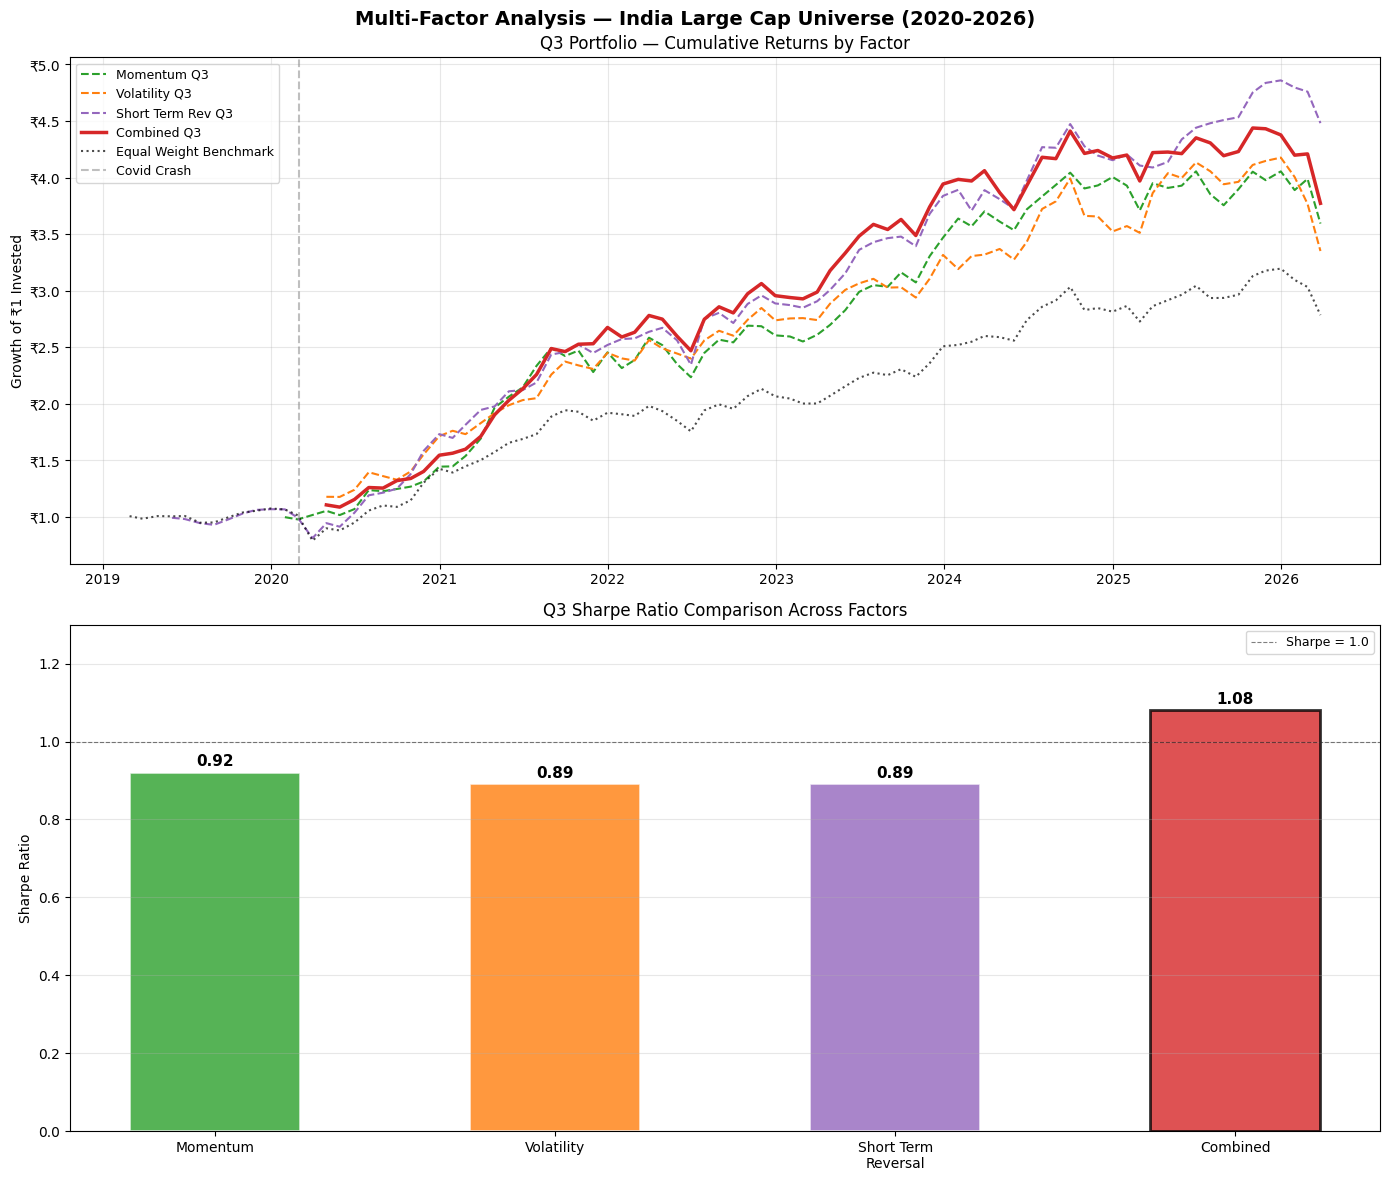

Chart saved to data/multi_factor_results.png


In [12]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('Multi-Factor Analysis — India Large Cap Universe (2020-2026)', 
             fontsize=14, fontweight='bold')

# ── Chart 1 — Cumulative returns of Q3 across all factors ──
ax1 = axes[0]

# Each factor's Q3 cumulative return
# Note — you need to have all four portfolio dataframes loaded
# momentum_portfolios, vol_portfolios, reversal_portfolios, combined_portfolios

factors_to_plot = {
    'Momentum Q3':       (momentum_portfolios['Q3'],   '#2ca02c'),
    'Volatility Q3':     (vol_portfolios['Q3'],        '#ff7f0e'),
    'Short Term Rev Q3': (reversal_portfolios['Q3'],   '#9467bd'),
    'Combined Q3':       (combined_portfolios['Q3'],   '#d62728'),
}

for label, (returns, color) in factors_to_plot.items():
    cumulative = (1 + returns.dropna()).cumprod()
    linewidth = 2.5 if label == 'Combined Q3' else 1.5
    linestyle = '-' if label == 'Combined Q3' else '--'
    ax1.plot(cumulative.index, cumulative.values,
             label=label, color=color, 
             linewidth=linewidth, linestyle=linestyle)

# Equal weight benchmark
benchmark = monthly_returns.mean(axis=1)
benchmark_cum = (1 + benchmark).cumprod()
ax1.plot(benchmark_cum.index, benchmark_cum.values,
         label='Equal Weight Benchmark', color='black',
         linewidth=1.5, linestyle=':', alpha=0.7)

ax1.axvline(pd.Timestamp('2020-03-01'), color='grey',
            linestyle='--', alpha=0.5, label='Covid Crash')
ax1.set_title('Q3 Portfolio — Cumulative Returns by Factor', fontsize=12)
ax1.set_ylabel('Growth of ₹1 Invested')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x:.1f}'))

# ── Chart 2 — Sharpe ratio comparison bar chart ──
ax2 = axes[1]

factor_names = ['Momentum', 'Volatility', 'Short Term\nReversal', 'Combined']
q3_sharpes   = [0.92, 0.89, 0.89, 1.08]
colors_bar   = ['#2ca02c', '#ff7f0e', '#9467bd', '#d62728']

bars = ax2.bar(factor_names, q3_sharpes, 
               color=colors_bar, alpha=0.8, 
               width=0.5, edgecolor='white', linewidth=1.2)

# Add value labels on top of each bar
for bar, val in zip(bars, q3_sharpes):
    ax2.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom',
             fontweight='bold', fontsize=11)

# Highlight combined bar
bars[3].set_edgecolor('black')
bars[3].set_linewidth(2)

ax2.axhline(y=1.0, color='black', linewidth=0.8, 
            linestyle='--', alpha=0.5, label='Sharpe = 1.0')
ax2.set_title('Q3 Sharpe Ratio Comparison Across Factors', fontsize=12)
ax2.set_ylabel('Sharpe Ratio')
ax2.set_ylim(0, 1.3)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('data/multi_factor_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to data/multi_factor_results.png")